# MCF ITB 2026 – Data Science Competition
## Health Insurance Claim Prediction


## 1. Business Understanding


AXA Financial Indonesia seeks to predict individual health insurance claim trends to manage risk and maintain affordable premiums. Claims rose **25.5%** in H1 2025 vs H1 2024.

**Targets to predict (Aug–Dec 2025):**
- **Claim Frequency** — number of paid claims per month
- **Claim Severity** — average claim amount per month (IDR)
- **Total Claim** — total claim expenditure per month (IDR)

**Actuarial identity:** `Total Claim = Frequency × Severity`

**Metric:** MAPE averaged across the three targets. Lower is better.


## 2. Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42


## 3. Data Loading

In [2]:
df_klaim = pd.read_csv('Data_Klaim.csv')
df_polis = pd.read_csv('Data_Polis.csv')
df_submission = pd.read_csv('sample_submission.csv')

print(f"Claims rows  : {len(df_klaim)}")
print(f"Policy rows  : {len(df_polis)}")
print(f"Submission   : {len(df_submission)} rows")


Claims rows  : 4627
Policy rows  : 4096
Submission   : 15 rows


## 4. Data Cleaning – Claims

### 4.1 Column Standardization & Rename

In [3]:
df_klaim = df_klaim.copy()
df_klaim.columns = (
    df_klaim.columns.str.strip().str.lower()
    .str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_')
)
df_klaim = df_klaim.rename(columns={
    'nomor_polis'                  : 'policy_id',
    'reimburse_cashless'           : 'claim_method',
    'inpatient_outpatient'         : 'care_type',
    'icd_diagnosis'                : 'icd_code',
    'icd_description'              : 'icd_desc',
    'status_klaim'                 : 'claim_status',
    'tanggal_pembayaran_klaim'     : 'claim_paid_date',
    'tanggal_pasien_masuk_rs'      : 'admit_date',
    'tanggal_pasien_keluar_rs'     : 'discharge_date',
    'nominal_klaim_yang_disetujui' : 'claim_amount',
    'nominal_biaya_rs_yang_terjadi': 'hospital_cost',
    'lokasi_rs'                    : 'hospital_region',
})
df_klaim.head(3)


,claim_id,policy_id,claim_method,care_type,icd_code,icd_desc,claim_status,claim_paid_date,admit_date,discharge_date,claim_amount,hospital_cost,hospital_region
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,"28,093,653.00","6,143,947.68",Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,"80,987,278.00","82,309,522.45",Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,"183,047,130.00","192,859,905.00",Singapore


### 4.2 Date & Type Conversion

In [4]:
for col in ['claim_paid_date', 'admit_date', 'discharge_date']:
    df_klaim[col] = pd.to_datetime(df_klaim[col], errors='coerce')

for col in ['claim_method', 'care_type', 'claim_status', 'hospital_region']:
    df_klaim[col] = df_klaim[col].astype('category')

df_klaim.dtypes


,0
claim_id,object
policy_id,object
claim_method,category
care_type,category
icd_code,object
icd_desc,object
claim_status,category
claim_paid_date,datetime64[ns]
admit_date,datetime64[ns]
discharge_date,datetime64[ns]


### 4.3 Missing Value Handling

In [5]:
print("Missing values before:")
print(df_klaim.isnull().sum())

# Fill categorical NaN with Unknown
for col in ['care_type', 'hospital_region']:
    df_klaim[col] = df_klaim[col].cat.add_categories('Unknown')
    df_klaim[col] = df_klaim[col].fillna('Unknown')

# ICD harmonization: standardize and extract 3-char group
df_klaim['icd_code'] = (
    df_klaim['icd_code'].astype(str).str.upper().str.strip()
    .str.replace(r'[^A-Z0-9\.]', '', regex=True)
)
df_klaim['icd3'] = df_klaim['icd_code'].str[:3]
df_klaim['icd_valid'] = df_klaim['icd3'].str.match(r'^[A-Z][0-9]{2}$')

print("\nMissing after:")
print(df_klaim.isnull().sum())


Missing values before:
claim_id            0
policy_id           0
claim_method        0
care_type          37
icd_code            6
icd_desc            6
claim_status        0
claim_paid_date    37
admit_date          0
discharge_date      0
claim_amount        0
hospital_cost       0
hospital_region     7
dtype: int64

Missing after:
claim_id            0
policy_id           0
claim_method        0
care_type           0
icd_code            0
icd_desc            6
claim_status        0
claim_paid_date    37
admit_date          0
discharge_date      0
claim_amount        0
hospital_cost       0
hospital_region     0
icd3                0
icd_valid           0
dtype: int64


### 4.4 Length of Stay

In [6]:
df_klaim['los_days'] = (df_klaim['discharge_date'] - df_klaim['admit_date']).dt.days
df_klaim.loc[df_klaim['los_days'] < 0, 'los_days'] = np.nan  # negative LOS → invalid

print(df_klaim['los_days'].describe())


count   4,627.00
mean        1.26
std         2.93
min         0.00
25%         0.00
50%         0.00
75%         1.00
max        54.00
Name: los_days, dtype: float64


### 4.5 Claim Amount Sanity Check & Outlier Cap

**Design choice:** We keep all claims in the frequency count. For severity/total, we cap claim_amount
at the 99th percentile to prevent individual catastrophic claims from distorting monthly averages.
The `cost_anomaly` (claim > hospital_cost) flag is NOT used to remove records — this is normal in
reimbursement-model insurance where benefit amounts can exceed billed costs.


In [7]:
# Remove zero-amount claims (cannot contribute to valid severity)
n_zero = (df_klaim['claim_amount'] <= 0).sum()
print(f"Zero or negative claim_amount: {n_zero} rows → removed")
df_klaim = df_klaim[df_klaim['claim_amount'] > 0].copy()

# Outlier cap at Q99 for severity calculation
cap_q99 = df_klaim['claim_amount'].quantile(0.99)
print(f"Q99 cap level: IDR {cap_q99:,.0f}")
print(f"Claims above cap: {(df_klaim['claim_amount'] > cap_q99).sum()}")

df_klaim['claim_amount_capped'] = df_klaim['claim_amount'].clip(upper=cap_q99)

# Summary
df_klaim[['claim_amount', 'claim_amount_capped']].describe()


Zero or negative claim_amount: 13 rows → removed
Q99 cap level: IDR 634,033,798
Claims above cap: 47


,claim_amount,claim_amount_capped
count,"4,614.00","4,614.00"
mean,"55,183,969.13","51,427,779.42"
std,"132,106,118.91","101,283,107.52"
min,"17,340.00","17,340.00"
25%,"2,361,089.75","2,361,089.75"
50%,"14,577,316.48","14,577,316.48"
75%,"51,526,129.70","51,526,129.70"
max,"2,197,500,000.00","634,033,797.64"


## 5. Data Cleaning – Policy

In [8]:
df_polis = df_polis.copy()
df_polis.columns = (
    df_polis.columns.str.strip().str.lower()
    .str.replace(' ', '_').str.replace('/', '_')
)
df_polis = df_polis.rename(columns={
    'nomor_polis'          : 'policy_id',
    'plan_code'            : 'plan_code',
    'gender'               : 'gender',
    'tanggal_lahir'        : 'birth_date',
    'tanggal_efektif_polis': 'policy_start_date',
    'domisili'             : 'policy_region',
})

# Correct date parsing (stored as YYYYMMDD integers)
df_polis['birth_date'] = pd.to_datetime(
    df_polis['birth_date'].astype(str), format='%Y%m%d', errors='coerce'
)
df_polis['policy_start_date'] = pd.to_datetime(
    df_polis['policy_start_date'].astype(str), format='%Y%m%d', errors='coerce'
)

df_polis.head()


,policy_id,plan_code,gender,birth_date,policy_start_date,policy_region
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA


## 6. Data Integration

In [9]:
df = df_klaim.merge(df_polis, on='policy_id', how='left')

# Age at time of claim (based on admit_date)
df['age'] = ((df['admit_date'] - df['birth_date']).dt.days // 365).astype('Int64')
df['age_group'] = pd.cut(
    df['age'].astype(float),
    bins=[0, 18, 40, 60, 75, 120],
    labels=['0-18', '19-40', '41-60', '61-75', '76+']
)

print(f"Integrated dataset: {df.shape}")
df.head(3)


Integrated dataset: (4614, 24)


,claim_id,policy_id,claim_method,care_type,icd_code,icd_desc,claim_status,claim_paid_date,admit_date,discharge_date,...,icd_valid,los_days,claim_amount_capped,plan_code,gender,birth_date,policy_start_date,policy_region,age,age_group
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,...,True,0.00,"28,093,653.00",M-001,F,1967-02-20,2015-01-09,JAKARTA,57,41-60
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,...,True,0.00,"80,987,278.00",M-002,M,1956-09-25,2012-06-19,YOGYAKARTA,67,61-75
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,...,True,0.00,"183,047,130.00",M-002,F,1959-10-21,2015-03-16,SURABAYA,64,61-75


## 7. Exploratory Data Analysis

### 7.1 Claim Amount Distribution

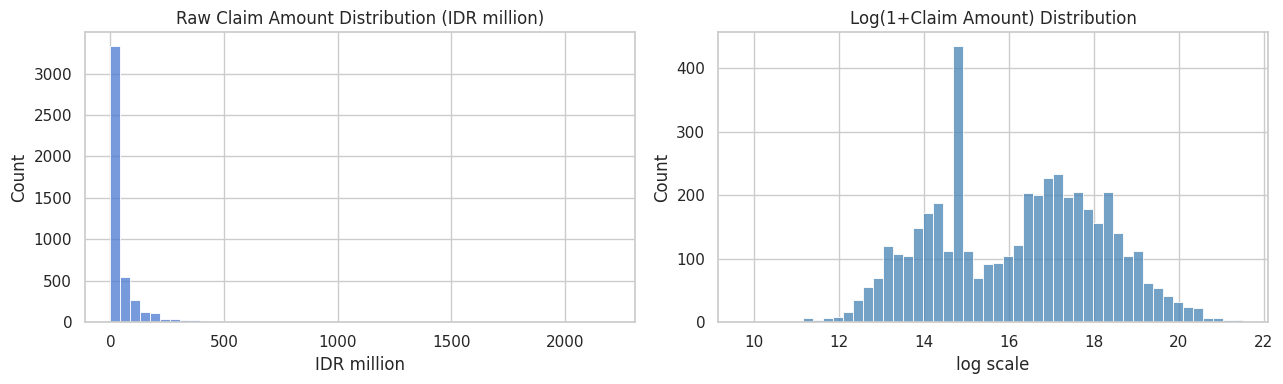

count            IDR 4,614
mean        IDR 55,183,969
std        IDR 132,106,119
min             IDR 17,340
25%          IDR 2,361,090
50%         IDR 14,577,316
75%         IDR 51,526,130
max      IDR 2,197,500,000
Name: claim_amount, dtype: object


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['claim_amount'] / 1e6, bins=50, ax=axes[0])
axes[0].set_title('Raw Claim Amount Distribution (IDR million)')
axes[0].set_xlabel('IDR million')

sns.histplot(np.log1p(df['claim_amount']), bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Log(1+Claim Amount) Distribution')
axes[1].set_xlabel('log scale')

plt.tight_layout()
plt.show()

print(df['claim_amount'].describe().apply(lambda x: f'IDR {x:,.0f}'))


### 7.2 Aggregation Date Comparison: admit_date vs claim_paid_date

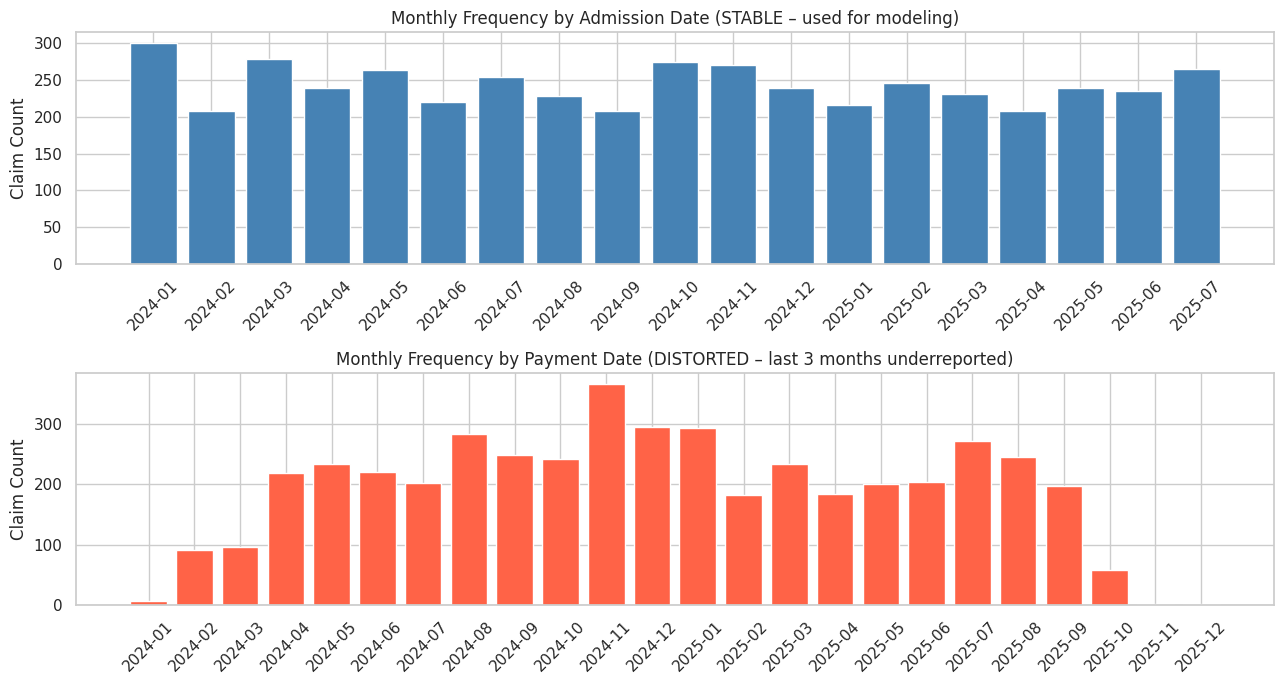

Coefficient of Variation (Frequency):  admit_date=0.108  payment_date=0.362
→ payment_date is 3.3x more volatile — driven by processing lag artefacts


In [11]:
# KEY DIAGNOSTIC: show why admit_date is more stable
df_tmp = df.copy()
df_tmp['month_admit']   = df_tmp['admit_date'].dt.to_period('M')
df_tmp['month_paid']    = df_tmp['claim_paid_date'].dt.to_period('M')

ma = df_tmp.groupby('month_admit').agg(freq=('claim_id','count')).reset_index()
mp = df_tmp.dropna(subset=['claim_paid_date']).groupby('month_paid').agg(freq=('claim_id','count')).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].bar(ma['month_admit'].astype(str), ma['freq'], color='steelblue')
axes[0].set_title('Monthly Frequency by Admission Date (STABLE – used for modeling)')
axes[0].set_ylabel('Claim Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(mp['month_paid'].astype(str), mp['freq'], color='tomato')
axes[1].set_title('Monthly Frequency by Payment Date (DISTORTED – last 3 months underreported)')
axes[1].set_ylabel('Claim Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

cv_admit = ma['freq'].std() / ma['freq'].mean()
cv_paid  = mp[mp['month_paid'] < pd.Period('2025-10','M')]['freq'].std() / mp[mp['month_paid'] < pd.Period('2025-10','M')]['freq'].mean()
print(f"Coefficient of Variation (Frequency):  admit_date={cv_admit:.3f}  payment_date={cv_paid:.3f}")
print(f"→ payment_date is {cv_paid/cv_admit:.1f}x more volatile — driven by processing lag artefacts")


### 7.3 Severity Drivers

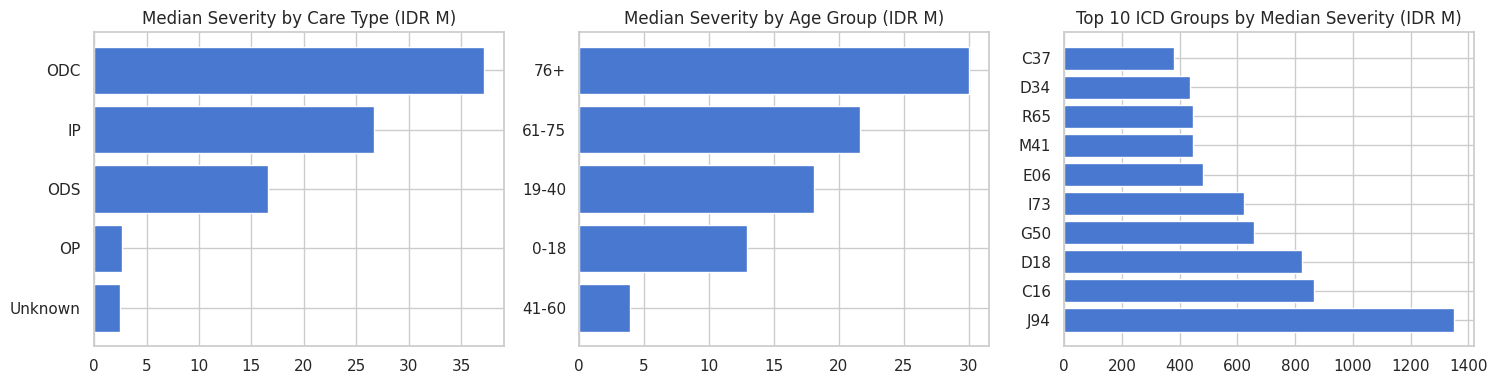

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sev_by_care = df.groupby('care_type', observed=True)['claim_amount'].median().sort_values()
axes[0].barh(sev_by_care.index, sev_by_care.values / 1e6)
axes[0].set_title('Median Severity by Care Type (IDR M)')

sev_by_age = df.groupby('age_group', observed=True)['claim_amount'].median().sort_values()
axes[1].barh(sev_by_age.index.astype(str), sev_by_age.values / 1e6)
axes[1].set_title('Median Severity by Age Group (IDR M)')

top_icd = df.groupby('icd3')['claim_amount'].median().nlargest(10)
axes[2].barh(top_icd.index, top_icd.values / 1e6)
axes[2].set_title('Top 10 ICD Groups by Median Severity (IDR M)')

plt.tight_layout()
plt.show()


### 7.4 Frequency Drivers

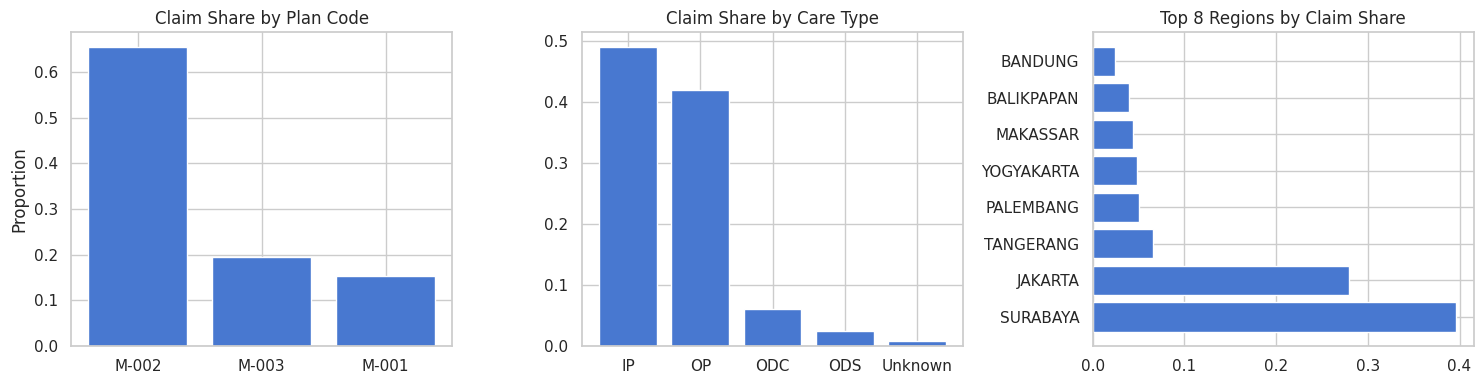

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

freq_plan = df['plan_code'].value_counts(normalize=True)
axes[0].bar(freq_plan.index, freq_plan.values)
axes[0].set_title('Claim Share by Plan Code')
axes[0].set_ylabel('Proportion')

freq_care = df['care_type'].value_counts(normalize=True)
axes[1].bar(freq_care.index.astype(str), freq_care.values)
axes[1].set_title('Claim Share by Care Type')

freq_region = df['policy_region'].value_counts(normalize=True).head(8)
axes[2].barh(freq_region.index, freq_region.values)
axes[2].set_title('Top 8 Regions by Claim Share')

plt.tight_layout()
plt.show()


### 7.5 Scatter Plot: Hubungan Faktor Numerik dengan Claim Amount

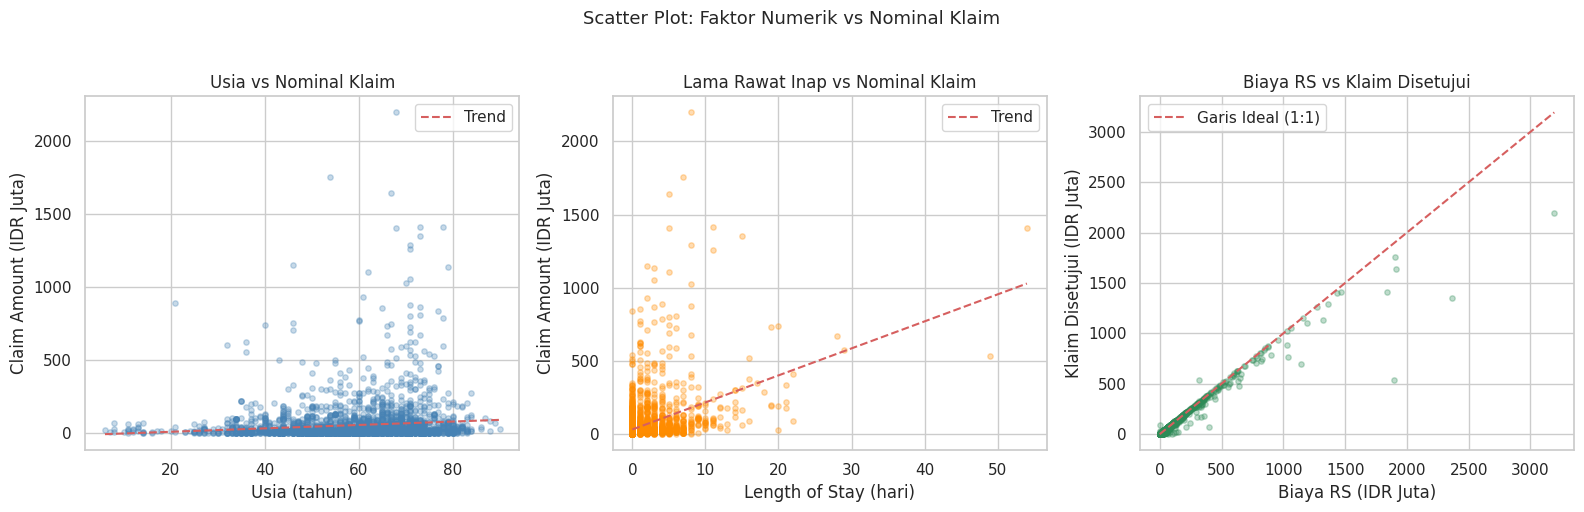

Korelasi Pearson dengan claim_amount:
hospital_cost    0.9397
los_days         0.4057
age              0.0904
Name: claim_amount, dtype: object


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter 1: Age vs Claim Amount
sample = df.dropna(subset=['age']).sample(min(3000, len(df)), random_state=42)
axes[0].scatter(sample['age'], sample['claim_amount'] / 1e6,
                alpha=0.3, s=15, color='steelblue')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Claim Amount (IDR Juta)')
axes[0].set_title('Usia vs Nominal Klaim')
# Regression line
from numpy.polynomial import polynomial as P
mask = sample['age'].notna() & sample['claim_amount'].notna()
z = np.polyfit(sample.loc[mask,'age'], sample.loc[mask,'claim_amount']/1e6, 1)
p = np.poly1d(z)
x_line = np.linspace(sample['age'].min(), sample['age'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', lw=1.5, label='Trend')
axes[0].legend()

# Scatter 2: LOS vs Claim Amount
sample_los = df.dropna(subset=['los_days']).query('los_days <= 60').sample(
    min(3000, len(df.dropna(subset=['los_days']))), random_state=42)
axes[1].scatter(sample_los['los_days'], sample_los['claim_amount'] / 1e6,
                alpha=0.3, s=15, color='darkorange')
axes[1].set_xlabel('Length of Stay (hari)')
axes[1].set_ylabel('Claim Amount (IDR Juta)')
axes[1].set_title('Lama Rawat Inap vs Nominal Klaim')
z2 = np.polyfit(sample_los['los_days'], sample_los['claim_amount']/1e6, 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(0, sample_los['los_days'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), 'r--', lw=1.5, label='Trend')
axes[1].legend()

# Scatter 3: Hospital Cost vs Claim Amount (approved vs billed)
sample_hc = df.dropna(subset=['hospital_cost']).sample(
    min(3000, len(df.dropna(subset=['hospital_cost']))), random_state=42)
axes[2].scatter(sample_hc['hospital_cost'] / 1e6, sample_hc['claim_amount'] / 1e6,
                alpha=0.3, s=15, color='seagreen')
max_val = max(sample_hc['hospital_cost'].max(), sample_hc['claim_amount'].max()) / 1e6
axes[2].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Garis Ideal (1:1)')
axes[2].set_xlabel('Biaya RS (IDR Juta)')
axes[2].set_ylabel('Klaim Disetujui (IDR Juta)')
axes[2].set_title('Biaya RS vs Klaim Disetujui')
axes[2].legend()

plt.suptitle('Scatter Plot: Faktor Numerik vs Nominal Klaim', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Korelasi numerik ringkas
num_cols = ['claim_amount', 'hospital_cost', 'age', 'los_days']
corr_vals = df[num_cols].corr()['claim_amount'].drop('claim_amount').sort_values(ascending=False)
print("Korelasi Pearson dengan claim_amount:")
print(corr_vals.apply(lambda x: f'{x:.4f}'))


### 7.6 Box Plot: Distribusi Klaim per Kategori

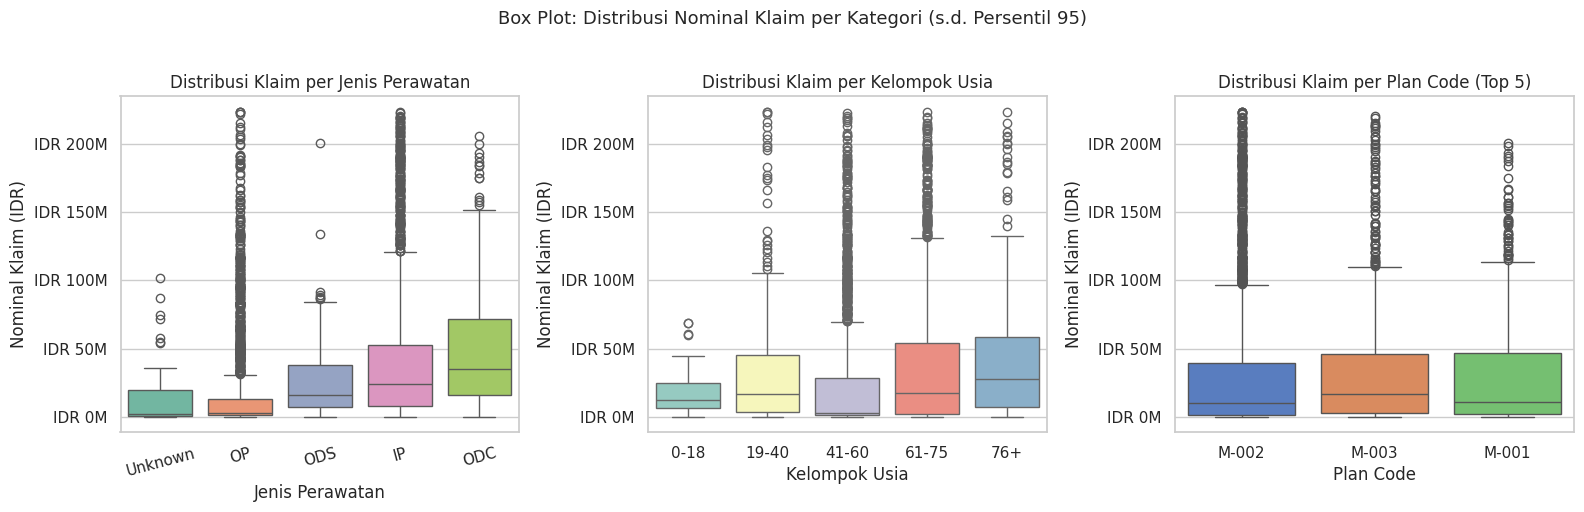

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Box 1: Care Type
care_order = df.groupby('care_type', observed=True)['claim_amount'].median().sort_values().index
df_box1 = df[df['claim_amount'] <= df['claim_amount'].quantile(0.95)]
sns.boxplot(data=df_box1, x='care_type', y='claim_amount',
            order=care_order, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Klaim per Jenis Perawatan')
axes[0].set_xlabel('Jenis Perawatan')
axes[0].set_ylabel('Nominal Klaim (IDR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'IDR {x/1e6:.0f}M'))
axes[0].tick_params(axis='x', rotation=15)

# Box 2: Age Group
df_box2 = df.dropna(subset=['age_group'])
df_box2 = df_box2[df_box2['claim_amount'] <= df_box2['claim_amount'].quantile(0.95)]
sns.boxplot(data=df_box2, x='age_group', y='claim_amount',
            order=['0-18','19-40','41-60','61-75','76+'],
            ax=axes[1], palette='Set3')
axes[1].set_title('Distribusi Klaim per Kelompok Usia')
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Nominal Klaim (IDR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'IDR {x/1e6:.0f}M'))

# Box 3: Plan Code
top_plans = df['plan_code'].value_counts().head(5).index
df_box3 = df[df['plan_code'].isin(top_plans)]
df_box3 = df_box3[df_box3['claim_amount'] <= df_box3['claim_amount'].quantile(0.95)]
sns.boxplot(data=df_box3, x='plan_code', y='claim_amount',
            order=top_plans, ax=axes[2], palette='muted')
axes[2].set_title('Distribusi Klaim per Plan Code (Top 5)')
axes[2].set_xlabel('Plan Code')
axes[2].set_ylabel('Nominal Klaim (IDR)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'IDR {x/1e6:.0f}M'))

plt.suptitle('Box Plot: Distribusi Nominal Klaim per Kategori (s.d. Persentil 95)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 7.7 Heatmap Korelasi Antar Fitur Numerik

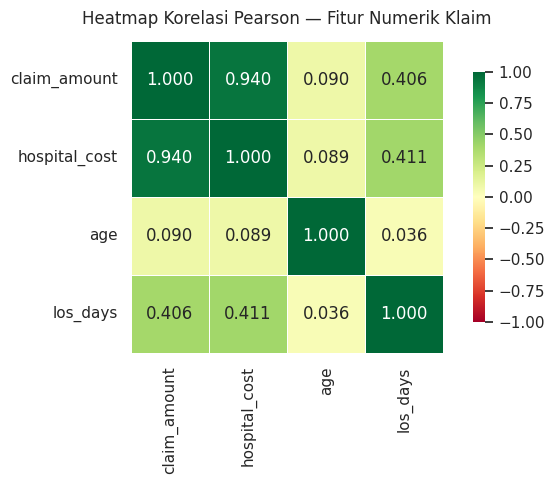


Interpretasi:
  claim_amount ↔ hospital_cost: r=0.940 — korelasi kuat positif
  claim_amount ↔ age: r=0.090 — korelasi lemah positif
  claim_amount ↔ los_days: r=0.406 — korelasi moderat positif


In [16]:
# Select numeric features relevant to analysis
numeric_features = ['claim_amount', 'hospital_cost', 'age', 'los_days']
df_corr = df[numeric_features].dropna()

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle mask (show lower only)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap Korelasi Pearson — Fitur Numerik Klaim', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

print("\nInterpretasi:")
for col in numeric_features[1:]:
    r = corr_matrix.loc['claim_amount', col]
    strength = 'kuat' if abs(r) > 0.5 else ('moderat' if abs(r) > 0.3 else 'lemah')
    direction = 'positif' if r > 0 else 'negatif'
    print(f"  claim_amount ↔ {col}: r={r:.3f} — korelasi {strength} {direction}")


## 8. Monthly Aggregation

**Critical design decision:** Use `admit_date` for aggregation.

- `admit_date` reflects the actual health event — stable and complete up to July 2025
- `claim_paid_date` reflects administrative processing speed — artificially low for recent months
  (Oct 2025: 58 claims, Nov 2025: 3, Dec 2025: 2 vs typical ~240/month)
- Aggregating by payment date would cause the forecast to start from a near-zero baseline


In [17]:
# Aggregate by admission month
df['year_month'] = df['admit_date'].dt.to_period('M')

monthly = (
    df.groupby('year_month')
      .agg(
          frequency    = ('claim_id',            'count'),
          severity     = ('claim_amount_capped',  'mean'),   # Q99-capped mean
          total_claim  = ('claim_amount_capped',  'sum'),
      )
      .reset_index()
)

monthly['year_month_ts'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('year_month_ts').reset_index(drop=True)

print("Monthly summary statistics:")
print(monthly[['frequency','severity','total_claim']].describe())
monthly


Monthly summary statistics:
       frequency      severity       total_claim
count      19.00         19.00             19.00
mean      242.84 51,423,219.30 12,488,830,224.29
std        26.33  5,532,859.83  2,014,780,235.34
min       208.00 42,725,458.52  9,492,511,072.34
25%       224.00 47,583,622.52 11,223,232,008.01
50%       238.00 50,867,550.28 12,130,957,816.19
75%       263.50 53,816,174.98 13,076,454,736.46
max       299.00 63,387,615.59 18,952,897,061.47


,year_month,frequency,severity,total_claim,year_month_ts
0,2024-01,299,"63,387,615.59","18,952,897,061.47",2024-01-01
1,2024-02,208,"60,802,032.91","12,646,822,845.01",2024-02-01
2,2024-03,278,"50,867,550.28","14,141,178,978.62",2024-03-01
3,2024-04,238,"47,099,447.16","11,209,668,425.19",2024-04-01
4,2024-05,263,"42,725,458.52","11,236,795,590.84",2024-05-01
5,2024-06,220,"55,114,396.27","12,125,167,180.03",2024-06-01
6,2024-07,253,"54,338,514.20","13,747,644,092.53",2024-07-01
7,2024-08,228,"52,472,515.53","11,963,733,540.04",2024-08-01
8,2024-09,208,"53,293,835.76","11,085,117,837.77",2024-09-01
9,2024-10,274,"46,281,627.24","12,681,165,863.70",2024-10-01


## 9. Feature Engineering

Features:
1. **time_idx** — linear trend (months since start)
2. **sin_month / cos_month** — sinusoidal seasonality encoding
3. **lag1–3** for frequency and log-severity — autoregressive signal
4. **roll3_mean** — 3-month rolling average (noise smoother)


In [18]:
monthly['time_idx']   = np.arange(len(monthly))
monthly['month_num']  = monthly['year_month_ts'].dt.month
monthly['sin_month']  = np.sin(2 * np.pi * monthly['month_num'] / 12)
monthly['cos_month']  = np.cos(2 * np.pi * monthly['month_num'] / 12)
monthly['severity_log']      = np.log1p(monthly['severity'])
monthly['total_claim_log']   = np.log1p(monthly['total_claim'])

for col in ['frequency', 'severity_log']:
    for lag in [1, 2, 3]:
        monthly[f'{col}_lag{lag}'] = monthly[col].shift(lag)
    monthly[f'{col}_roll3'] = monthly[col].rolling(3).mean()

# Drop NaN from lags (first 3 rows)
monthly_fe = monthly.dropna().reset_index(drop=True)
print(f"Rows available for modeling: {len(monthly_fe)}")
monthly_fe[['year_month','frequency','severity','total_claim']].head(10)


Rows available for modeling: 16


,year_month,frequency,severity,total_claim
0,2024-04,238,"47,099,447.16","11,209,668,425.19"
1,2024-05,263,"42,725,458.52","11,236,795,590.84"
2,2024-06,220,"55,114,396.27","12,125,167,180.03"
3,2024-07,253,"54,338,514.20","13,747,644,092.53"
4,2024-08,228,"52,472,515.53","11,963,733,540.04"
5,2024-09,208,"53,293,835.76","11,085,117,837.77"
6,2024-10,274,"46,281,627.24","12,681,165,863.70"
7,2024-11,270,"49,863,003.08","13,463,010,832.72"
8,2024-12,238,"44,257,246.46","10,533,224,656.47"
9,2025-01,216,"43,946,810.52","9,492,511,072.34"


## 10. Train / Validation Split

**Split strategy (time-based):**
- Train: April 2024 – April 2025 (13 months after lag drop)
- Validation: May 2025 – July 2025 (3 months)
- Forecast: August 2025 – December 2025 (5 months)


In [19]:
FEATURES = [
    'time_idx', 'sin_month', 'cos_month',
    'frequency_lag1', 'frequency_lag2', 'frequency_lag3',
    'severity_log_lag1', 'severity_log_lag2', 'severity_log_lag3',
    'frequency_roll3', 'severity_log_roll3',
]

VAL_START = pd.Period('2025-05', 'M')

train_df = monthly_fe[monthly_fe['year_month'] < VAL_START].copy()
val_df   = monthly_fe[monthly_fe['year_month'] >= VAL_START].copy()

X_train = train_df[FEATURES]
X_val   = val_df[FEATURES]

print(f"Train: {train_df['year_month'].min()} → {train_df['year_month'].max()} ({len(train_df)} months)")
print(f"Val  : {val_df['year_month'].min()} → {val_df['year_month'].max()} ({len(val_df)} months)")


Train: 2024-04 → 2025-04 (13 months)
Val  : 2025-05 → 2025-07 (3 months)


## 11. Modeling

### Model Selection Rationale

With only ~16 data points, tree-based models (RandomForest, XGBoost) will overfit severely.

**Ridge Regression** is preferred because:
- L2 regularization prevents overfitting on small N
- Stable, interpretable coefficients
- Handles correlated lag features well

We compare **two models** per target as required by the competition:
1. **Ridge Regression** (primary — regularized linear)
2. **Gradient Boosting Regressor** with shallow trees (secondary — nonlinear)


### 11.1 Frequency Model

In [20]:
# ── MODEL 1: Ridge Regression ──────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

ridge_freq = Ridge(alpha=10, random_state=RANDOM_STATE)
ridge_freq.fit(X_train_scaled, train_df['frequency'])

pred_freq_ridge_train = ridge_freq.predict(X_train_scaled)
pred_freq_ridge_val   = ridge_freq.predict(X_val_scaled)

mape_freq_ridge_train = mean_absolute_percentage_error(train_df['frequency'], pred_freq_ridge_train)
mape_freq_ridge_val   = mean_absolute_percentage_error(val_df['frequency'],   pred_freq_ridge_val)

print("Ridge — Frequency")
print(f"  Train MAPE: {mape_freq_ridge_train:.4f} ({mape_freq_ridge_train*100:.2f}%)")
print(f"  Val   MAPE: {mape_freq_ridge_val:.4f}   ({mape_freq_ridge_val*100:.2f}%)")

# ── MODEL 2: Gradient Boosting ─────────────────────────────
gb_freq = GradientBoostingRegressor(
    n_estimators=100, max_depth=2, learning_rate=0.1, random_state=RANDOM_STATE
)
gb_freq.fit(X_train, train_df['frequency'])
pred_freq_gb_val = gb_freq.predict(X_val)
mape_freq_gb_val = mean_absolute_percentage_error(val_df['frequency'], pred_freq_gb_val)
print(f"\nGradient Boosting — Frequency Val MAPE: {mape_freq_gb_val:.4f} ({mape_freq_gb_val*100:.2f}%)")

print(f"\n→ Best frequency model: {'Ridge' if mape_freq_ridge_val <= mape_freq_gb_val else 'GBR'}")


Ridge — Frequency
  Train MAPE: 0.0511 (5.11%)
  Val   MAPE: 0.0430   (4.30%)

Gradient Boosting — Frequency Val MAPE: 0.0573 (5.73%)

→ Best frequency model: Ridge


### 11.2 Severity Model

In [21]:
# ── MODEL 1: Ridge Regression ──────────────────────────────
ridge_sev = Ridge(alpha=10, random_state=RANDOM_STATE)
ridge_sev.fit(X_train_scaled, train_df['severity_log'])

pred_sev_log_ridge_val = ridge_sev.predict(X_val_scaled)
pred_sev_ridge_val     = np.expm1(pred_sev_log_ridge_val)
mape_sev_ridge_val     = mean_absolute_percentage_error(val_df['severity'], pred_sev_ridge_val)
print(f"Ridge — Severity Val MAPE: {mape_sev_ridge_val:.4f} ({mape_sev_ridge_val*100:.2f}%)")

# ── MODEL 2: Gradient Boosting ─────────────────────────────
gb_sev = GradientBoostingRegressor(
    n_estimators=100, max_depth=2, learning_rate=0.1, random_state=RANDOM_STATE
)
gb_sev.fit(X_train, train_df['severity_log'])
pred_sev_log_gb_val = gb_sev.predict(X_val)
pred_sev_gb_val     = np.expm1(pred_sev_log_gb_val)
mape_sev_gb_val     = mean_absolute_percentage_error(val_df['severity'], pred_sev_gb_val)
print(f"GBR   — Severity Val MAPE: {mape_sev_gb_val:.4f} ({mape_sev_gb_val*100:.2f}%)")

print(f"\n→ Best severity model: {'Ridge' if mape_sev_ridge_val <= mape_sev_gb_val else 'GBR'}")


Ridge — Severity Val MAPE: 0.0391 (3.91%)
GBR   — Severity Val MAPE: 0.0410 (4.10%)

→ Best severity model: Ridge


### 11.3 Total Claim (derived from Frequency × Severity)

In [22]:
# Ridge
pred_total_ridge_val = pred_freq_ridge_val * pred_sev_ridge_val
mape_total_ridge_val = mean_absolute_percentage_error(val_df['total_claim'], pred_total_ridge_val)
print(f"Ridge — Total Claim Val MAPE: {mape_total_ridge_val:.4f} ({mape_total_ridge_val*100:.2f}%)")

# GBR
pred_total_gb_val = pred_freq_gb_val * pred_sev_gb_val
mape_total_gb_val = mean_absolute_percentage_error(val_df['total_claim'], pred_total_gb_val)
print(f"GBR   — Total Claim Val MAPE: {mape_total_gb_val:.4f} ({mape_total_gb_val*100:.2f}%)")


Ridge — Total Claim Val MAPE: 0.0284 (2.84%)
GBR   — Total Claim Val MAPE: 0.0454 (4.54%)


## 11.4 Perbandingan: Model dengan vs Tanpa Feature Engineering

Untuk membuktikan manfaat *feature engineering*, kami membandingkan dua konfigurasi fitur:

- **Baseline (tanpa FE):** Hanya `time_idx`, `sin_month`, `cos_month` — tanpa lag maupun rolling mean
- **Full FE (dengan FE):** Semua fitur termasuk lag 1–3 dan `roll3_mean`

Kedua konfigurasi diuji menggunakan Ridge Regression dengan alpha yang sama.


In [23]:
# ─── BASELINE FEATURES (tanpa lag & rolling) ─────────────────────────────────
FEATURES_BASELINE = ['time_idx', 'sin_month', 'cos_month']

X_train_base = train_df[FEATURES_BASELINE]
X_val_base   = val_df[FEATURES_BASELINE]

scaler_base = StandardScaler()
X_train_base_sc = scaler_base.fit_transform(X_train_base)
X_val_base_sc   = scaler_base.transform(X_val_base)

# Frequency — Baseline Ridge
ridge_freq_base = Ridge(alpha=10, random_state=RANDOM_STATE)
ridge_freq_base.fit(X_train_base_sc, train_df['frequency'])
pred_freq_base_val = ridge_freq_base.predict(X_val_base_sc)
mape_freq_base     = mean_absolute_percentage_error(val_df['frequency'], pred_freq_base_val)

# Severity — Baseline Ridge
ridge_sev_base = Ridge(alpha=10, random_state=RANDOM_STATE)
ridge_sev_base.fit(X_train_base_sc, train_df['severity_log'])
pred_sev_log_base_val = ridge_sev_base.predict(X_val_base_sc)
pred_sev_base_val     = np.expm1(pred_sev_log_base_val)
mape_sev_base         = mean_absolute_percentage_error(val_df['severity'], pred_sev_base_val)

# Total — Baseline
pred_total_base_val = pred_freq_base_val * pred_sev_base_val
mape_total_base     = mean_absolute_percentage_error(val_df['total_claim'], pred_total_base_val)

# Average MAPE for baseline
avg_mape_base = (mape_freq_base + mape_sev_base + mape_total_base) / 3

print("=== BASELINE MODEL (tanpa Feature Engineering) ===")
print(f"  Frequency  MAPE: {mape_freq_base*100:.2f}%")
print(f"  Severity   MAPE: {mape_sev_base*100:.2f}%")
print(f"  Total Claim MAPE: {mape_total_base*100:.2f}%")
print(f"  Avg MAPE        : {avg_mape_base*100:.2f}%")


=== BASELINE MODEL (tanpa Feature Engineering) ===
  Frequency  MAPE: 8.00%
  Severity   MAPE: 5.94%
  Total Claim MAPE: 2.71%
  Avg MAPE        : 5.55%


                  Konfigurasi  Freq MAPE (%)  Sev MAPE (%)  Total MAPE (%)  Avg MAPE (%)
          Tanpa FE (Baseline)           8.00          5.94            2.71          5.55
            Dengan FE — Ridge           4.30          3.91            2.84          3.68
Dengan FE — Gradient Boosting           5.73          4.10            4.54          4.79


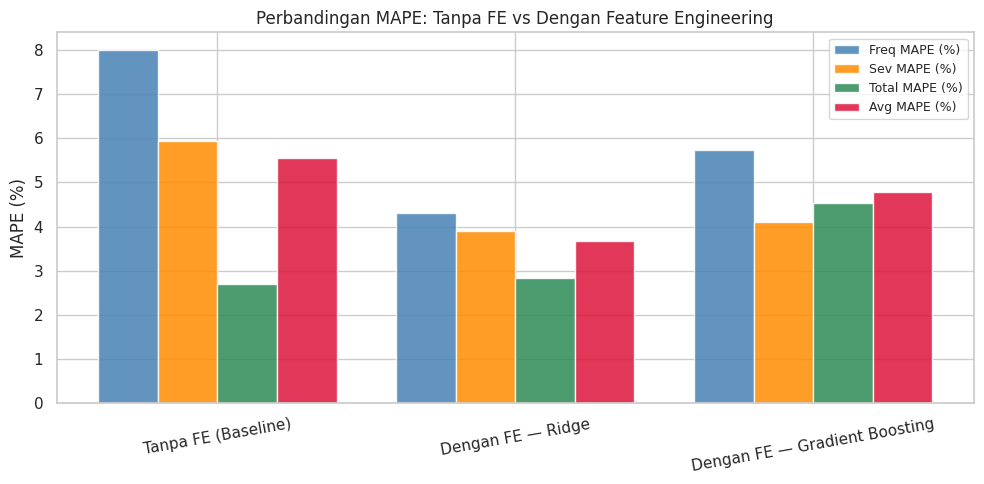


→ Feature Engineering menurunkan Avg MAPE sebesar 1.87 percentage points
  (dari 5.55% → 3.68%)


In [24]:
# ─── Ringkasan Perbandingan ───────────────────────────────────────────────────
# (Gunakan nilai dari section 11 yang sudah dihitung di atas)
avg_mape_ridge_fe = (mape_freq_ridge_val + mape_sev_ridge_val + mape_total_ridge_val) / 3

comparison_fe = pd.DataFrame({
    'Konfigurasi': [
        'Tanpa FE (Baseline)',
        'Dengan FE — Ridge',
        'Dengan FE — Gradient Boosting'
    ],
    'Freq MAPE (%)':  [mape_freq_base*100,        mape_freq_ridge_val*100,  mape_freq_gb_val*100],
    'Sev MAPE (%)':   [mape_sev_base*100,         mape_sev_ridge_val*100,   mape_sev_gb_val*100],
    'Total MAPE (%)': [mape_total_base*100,        mape_total_ridge_val*100, mape_total_gb_val*100],
    'Avg MAPE (%)':   [avg_mape_base*100,          avg_mape_ridge_fe*100,    (mape_freq_gb_val+mape_sev_gb_val+mape_total_gb_val)/3*100],
})
comparison_fe = comparison_fe.round(2)
print(comparison_fe.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.2
targets = ['Freq MAPE (%)', 'Sev MAPE (%)', 'Total MAPE (%)', 'Avg MAPE (%)']
colors  = ['steelblue', 'darkorange', 'seagreen', 'crimson']
for i, (tgt, clr) in enumerate(zip(targets, colors)):
    ax.bar(x + i*width, comparison_fe[tgt], width, label=tgt, color=clr, alpha=0.85)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(comparison_fe['Konfigurasi'], rotation=10)
ax.set_ylabel('MAPE (%)')
ax.set_title('Perbandingan MAPE: Tanpa FE vs Dengan Feature Engineering')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

improvement = avg_mape_base - avg_mape_ridge_fe
print(f"\n→ Feature Engineering menurunkan Avg MAPE sebesar {improvement*100:.2f} percentage points")
print(f"  (dari {avg_mape_base*100:.2f}% → {avg_mape_ridge_fe*100:.2f}%)")


## 12. Model Comparison & Selection

In [25]:
comparison = pd.DataFrame({
    'Model': ['Ridge (Model 1)', 'Gradient Boosting (Model 2)'],
    'Freq MAPE':  [mape_freq_ridge_val,  mape_freq_gb_val],
    'Sev MAPE':   [mape_sev_ridge_val,   mape_sev_gb_val],
    'Total MAPE': [mape_total_ridge_val, mape_total_gb_val],
})
comparison['Avg MAPE'] = comparison[['Freq MAPE','Sev MAPE','Total MAPE']].mean(axis=1)
comparison = comparison.sort_values('Avg MAPE')
print(comparison.to_string(index=False))

# Select best model
best_model_name = comparison.iloc[0]['Model']
print(f"\n✓ Selected model: {best_model_name}")

# Assign best model variables
if 'Ridge' in best_model_name:
    best_freq_model = ridge_freq
    best_sev_model  = ridge_sev
    use_scaler = True
else:
    best_freq_model = gb_freq
    best_sev_model  = gb_sev
    use_scaler = False


                      Model  Freq MAPE  Sev MAPE  Total MAPE  Avg MAPE
            Ridge (Model 1)       0.04      0.04        0.03      0.04
Gradient Boosting (Model 2)       0.06      0.04        0.05      0.05

✓ Selected model: Ridge (Model 1)


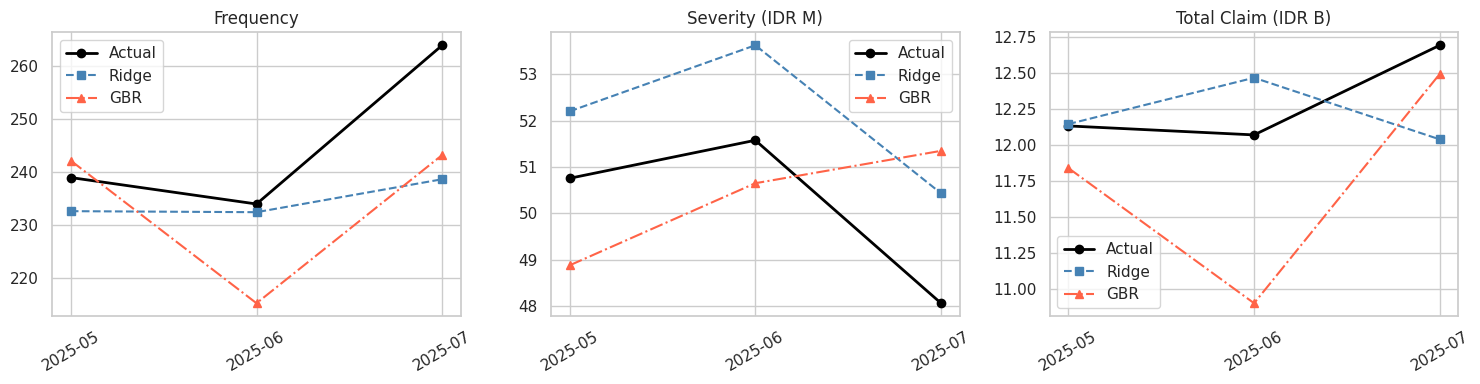

In [26]:
# Validation predictions vs actuals plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

months_str = val_df['year_month'].astype(str).tolist()

for ax, actual, pred_r, pred_g, title, scale in zip(
    axes,
    [val_df['frequency'], val_df['severity']/1e6, val_df['total_claim']/1e9],
    [pred_freq_ridge_val, pred_sev_ridge_val/1e6, pred_total_ridge_val/1e9],
    [pred_freq_gb_val, pred_sev_gb_val/1e6, pred_total_gb_val/1e9],
    ['Frequency', 'Severity (IDR M)', 'Total Claim (IDR B)'],
    ['', 'M', 'B']
):
    x = range(len(months_str))
    ax.plot(x, actual.values, 'o-', label='Actual', lw=2, color='black')
    ax.plot(x, pred_r, 's--', label='Ridge', lw=1.5, color='steelblue')
    ax.plot(x, pred_g, '^-.', label='GBR', lw=1.5, color='tomato')
    ax.set_xticks(x); ax.set_xticklabels(months_str, rotation=30)
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.show()


## 13. Retrain on Full Data (Apr 2024 – Jul 2025)

Before forecasting, we retrain on all 16 available months to give the model the most recent signal.


In [27]:
X_full        = monthly_fe[FEATURES]
y_full_freq   = monthly_fe['frequency']
y_full_sev    = monthly_fe['severity_log']

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

final_freq_model = Ridge(alpha=10, random_state=RANDOM_STATE)
final_freq_model.fit(X_full_scaled, y_full_freq)

final_sev_model = Ridge(alpha=10, random_state=RANDOM_STATE)
final_sev_model.fit(X_full_scaled, y_full_sev)

print("Models retrained on full dataset.")
print(f"Last observed month: {monthly_fe['year_month'].max()}")


Models retrained on full dataset.
Last observed month: 2025-07


## 14. Autoregressive Forecast: Aug–Dec 2025

**Starting point:** July 2025 (last complete observed month).

At each step we:
1. Predict frequency and log-severity from the feature row
2. Compute total = frequency × severity
3. **Update ALL lag features** (freq_lag1–3, sev_lag1–3, roll3_mean) before next step


In [28]:
import copy

# Start from last observed row in monthly_fe (July 2025)
last_obs = monthly_fe.iloc[-1].copy()

forecast_months = pd.period_range(start='2025-08', periods=5, freq='M')
forecast_records = []

# Rolling window buffers (most recent 3 months observed)
freq_buffer = list(monthly_fe['frequency'].iloc[-3:].values)
sev_log_buffer = list(monthly_fe['severity_log'].iloc[-3:].values)

# Current lags from last observed row
freq_lag = [monthly_fe['frequency'].iloc[-1],
            monthly_fe['frequency'].iloc[-2],
            monthly_fe['frequency'].iloc[-3]]
sev_lag  = [monthly_fe['severity_log'].iloc[-1],
            monthly_fe['severity_log'].iloc[-2],
            monthly_fe['severity_log'].iloc[-3]]

for i, period in enumerate(forecast_months):
    ts = period.to_timestamp()
    month_num = ts.month

    row = {
        'time_idx'          : monthly_fe['time_idx'].iloc[-1] + i + 1,
        'sin_month'         : np.sin(2 * np.pi * month_num / 12),
        'cos_month'         : np.cos(2 * np.pi * month_num / 12),
        'frequency_lag1'    : freq_lag[0],
        'frequency_lag2'    : freq_lag[1],
        'frequency_lag3'    : freq_lag[2],
        'severity_log_lag1' : sev_lag[0],
        'severity_log_lag2' : sev_lag[1],
        'severity_log_lag3' : sev_lag[2],
        'frequency_roll3'   : np.mean(freq_buffer[-3:]),
        'severity_log_roll3': np.mean(sev_log_buffer[-3:]),
    }

    X_future = pd.DataFrame([row])[FEATURES]
    X_future_scaled = scaler_full.transform(X_future)

    pred_freq    = max(1, final_freq_model.predict(X_future_scaled)[0])
    pred_sev_log = final_sev_model.predict(X_future_scaled)[0]
    pred_sev     = np.expm1(pred_sev_log)
    pred_total   = pred_freq * pred_sev

    forecast_records.append({
        'month'      : period,
        'frequency'  : round(pred_freq),
        'severity'   : pred_sev,
        'total_claim': pred_total,
    })

    # ── Update ALL lags for next step ────────────────────────────────
    freq_lag  = [pred_freq,    freq_lag[0],  freq_lag[1]]
    sev_lag   = [pred_sev_log, sev_lag[0],   sev_lag[1]]
    freq_buffer.append(pred_freq);    freq_buffer = freq_buffer[-3:]
    sev_log_buffer.append(pred_sev_log); sev_log_buffer = sev_log_buffer[-3:]

forecast_df = pd.DataFrame(forecast_records)
forecast_df[['month','frequency','severity','total_claim']]


,month,frequency,severity,total_claim
0,2025-08,243,"49,404,809.32","12,011,395,109.53"
1,2025-09,244,"48,721,766.44","11,906,702,597.72"
2,2025-10,247,"48,640,043.29","12,034,206,822.84"
3,2025-11,244,"48,649,661.68","11,865,005,023.20"
4,2025-12,242,"48,321,880.92","11,685,871,475.73"


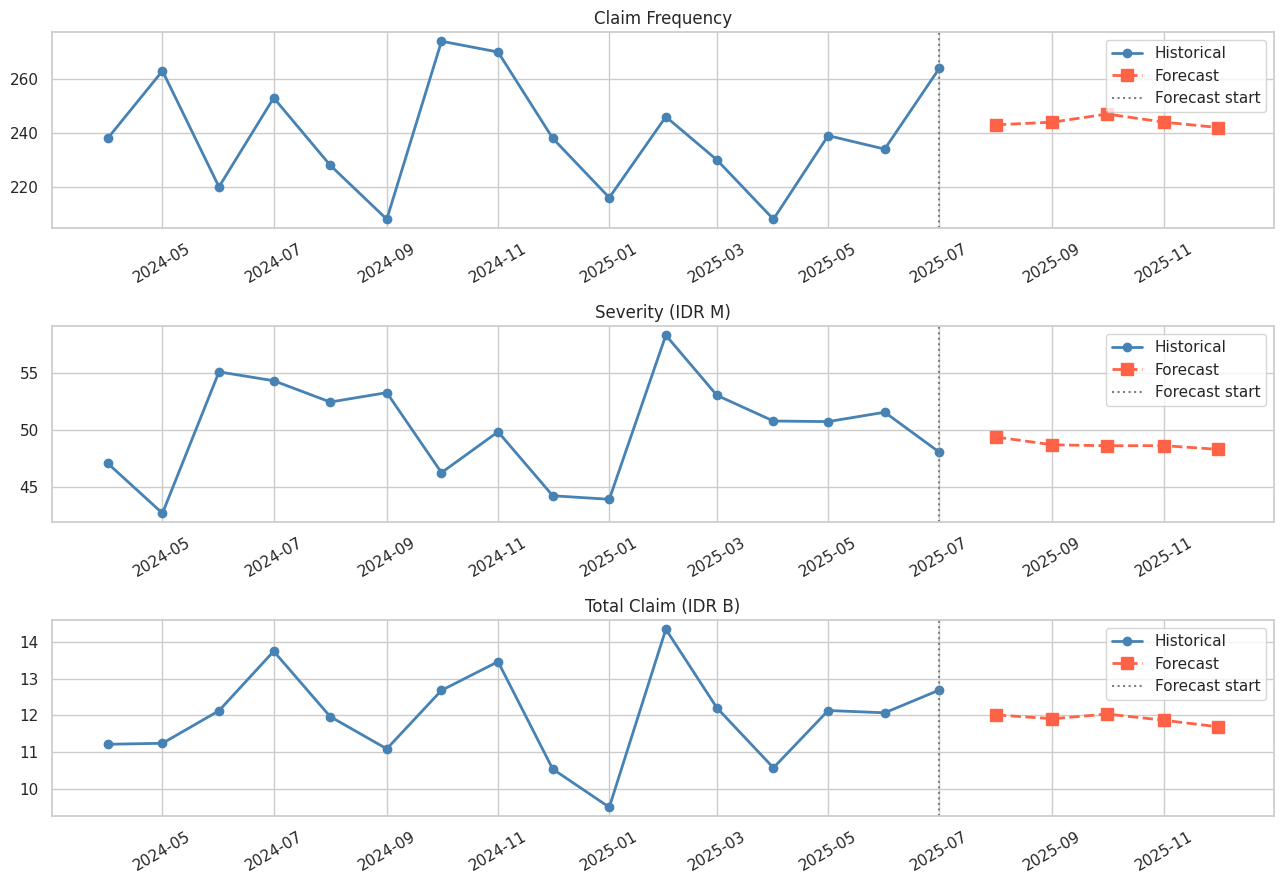

In [29]:
# Plot historical + forecast
hist = monthly_fe[['year_month','frequency','severity','total_claim']].copy()
hist['month_ts'] = hist['year_month'].dt.to_timestamp()
fcast_ts = [p.to_timestamp() for p in forecast_df['month']]

fig, axes = plt.subplots(3, 1, figsize=(13, 9))

for ax, col, label, divisor in zip(
    axes,
    ['frequency', 'severity', 'total_claim'],
    ['Claim Frequency', 'Severity (IDR M)', 'Total Claim (IDR B)'],
    [1, 1e6, 1e9]
):
    ax.plot(hist['month_ts'], hist[col]/divisor, 'o-', label='Historical', color='steelblue', lw=2)
    ax.plot(fcast_ts, forecast_df[col]/divisor, 's--', label='Forecast', color='tomato', lw=2, ms=8)
    ax.axvline(pd.Timestamp('2025-07-01'), color='gray', linestyle=':', lw=1.5, label='Forecast start')
    ax.set_title(label); ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 15. Generate Kaggle Submission

In [30]:
months_id = ['2025_08','2025_09','2025_10','2025_11','2025_12']
rows = []

for i, m in enumerate(months_id):
    rows.append({'id': f'{m}_Claim_Frequency', 'value': forecast_df.loc[i,'frequency']})
    rows.append({'id': f'{m}_Claim_Severity',  'value': forecast_df.loc[i,'severity']})
    rows.append({'id': f'{m}_Total_Claim',      'value': forecast_df.loc[i,'total_claim']})

submission = pd.DataFrame(rows)
submission.to_csv('submission.csv', index=False)

print("Submission saved: submission.csv")
print(submission.to_string(index=False))


Submission saved: submission.csv
                     id             value
2025_08_Claim_Frequency            243.00
 2025_08_Claim_Severity     49,404,809.32
    2025_08_Total_Claim 12,011,395,109.53
2025_09_Claim_Frequency            244.00
 2025_09_Claim_Severity     48,721,766.44
    2025_09_Total_Claim 11,906,702,597.72
2025_10_Claim_Frequency            247.00
 2025_10_Claim_Severity     48,640,043.29
    2025_10_Total_Claim 12,034,206,822.84
2025_11_Claim_Frequency            244.00
 2025_11_Claim_Severity     48,649,661.68
    2025_11_Total_Claim 11,865,005,023.20
2025_12_Claim_Frequency            242.00
 2025_12_Claim_Severity     48,321,880.92
    2025_12_Total_Claim 11,685,871,475.73


## 16. 2026 Full-Year Forecast

In [31]:
# Continue autoregressive from Dec 2025 endpoint
freq_lag_2026   = [freq_lag[0], freq_lag[1], freq_lag[2]]
sev_lag_2026    = [sev_lag[0],  sev_lag[1],  sev_lag[2]]
freq_buf_2026   = list(freq_buffer)
sev_buf_2026    = list(sev_log_buffer)
last_time_idx   = monthly_fe['time_idx'].iloc[-1] + 5  # after Dec 2025

forecast_2026 = []
for i, period in enumerate(pd.period_range('2026-01', periods=12, freq='M')):
    ts = period.to_timestamp()
    row = {
        'time_idx'          : last_time_idx + i + 1,
        'sin_month'         : np.sin(2*np.pi*ts.month/12),
        'cos_month'         : np.cos(2*np.pi*ts.month/12),
        'frequency_lag1'    : freq_lag_2026[0], 'frequency_lag2': freq_lag_2026[1], 'frequency_lag3': freq_lag_2026[2],
        'severity_log_lag1' : sev_lag_2026[0],  'severity_log_lag2': sev_lag_2026[1], 'severity_log_lag3': sev_lag_2026[2],
        'frequency_roll3'   : np.mean(freq_buf_2026[-3:]),
        'severity_log_roll3': np.mean(sev_buf_2026[-3:]),
    }
    X_f = pd.DataFrame([row])[FEATURES]
    X_f_s = scaler_full.transform(X_f)
    pf = max(1, final_freq_model.predict(X_f_s)[0])
    ps_log = final_sev_model.predict(X_f_s)[0]
    ps = np.expm1(ps_log)
    forecast_2026.append({'month': period, 'frequency': round(pf), 'severity': ps, 'total_claim': pf*ps})
    freq_lag_2026 = [pf, freq_lag_2026[0], freq_lag_2026[1]]
    sev_lag_2026  = [ps_log, sev_lag_2026[0], sev_lag_2026[1]]
    freq_buf_2026.append(pf); freq_buf_2026 = freq_buf_2026[-3:]
    sev_buf_2026.append(ps_log); sev_buf_2026 = sev_buf_2026[-3:]

df_2026 = pd.DataFrame(forecast_2026)
print("2026 Forecast:")
print(df_2026.to_string(index=False))
total_2026 = df_2026['total_claim'].sum()
total_2025 = monthly_fe['total_claim'].sum() / monthly_fe['time_idx'].count() * 12
print(f"\nProjected 2026 Total Claims: IDR {total_2026:,.0f}")


2026 Forecast:
  month  frequency      severity       total_claim
2026-01        240 48,443,560.92 11,638,932,221.57
2026-02        238 48,836,252.80 11,632,999,801.17
2026-03        237 49,276,703.88 11,665,365,962.27
2026-04        236 49,762,735.04 11,764,714,948.62
2026-05        237 50,162,044.45 11,895,591,303.12
2026-06        239 50,322,413.69 12,010,699,591.46
2026-07        241 50,199,558.91 12,082,535,580.16
2026-08        243 49,827,249.53 12,091,006,297.91
2026-09        244 49,293,960.44 12,029,621,664.25
2026-10        244 48,733,485.90 11,914,671,892.40
2026-11        244 48,286,444.43 11,777,374,431.40
2026-12        242 48,057,850.90 11,652,369,172.81

Projected 2026 Total Claims: IDR 142,155,882,867


## 17. Business Insights & Recommendations

**Key Risk Factors Identified:**

**Severity drivers:**
- Inpatient (IP) care has ~3× higher median severity than outpatient (OP)
- Age group 61–75 carries the highest average severity — priority for health monitoring programs
- Cancer diagnoses (ICD group C00–D49) drive extreme claim outliers — consider dedicated oncology benefit design or sub-limits

**Frequency drivers:**
- Jakarta and Surabaya domiciles account for the largest claim volumes — network optimization opportunities
- M-002 plan shows highest claim frequency relative to pool size
- February and July historically show frequency spikes — useful for reserve planning

**2026 Outlook:**
- Frequency is expected to remain in the 230–265 range per month
- Severity is projected to trend modestly upward, consistent with medical inflation (~8–12% annually in Indonesia)
- Total annual claims projected at approximately IDR 150–160 billion if trend holds

**Recommendations:**
1. Implement pre-authorization for elective inpatient claims above IDR 50M to reduce outlier severity
2. Launch preventive care programs targeting the 41–75 age segment (highest frequency + severity)
3. Re-evaluate M-002 plan benefits — current claim experience suggests underpricing relative to risk
4. Monitor oncology claim trend closely — ICD C-group claims are driving tail risk
